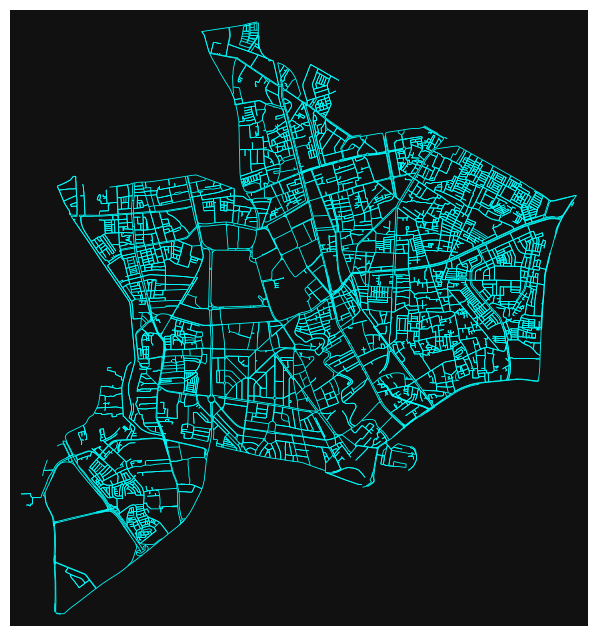

In [4]:
import osmnx as ox
import matplotlib.pyplot as plt

ox.settings.use_cache = True
ox.settings.log_console = True

print("Downloading Jakarta road network topology...")
G = ox.graph_from_place("Jakarta Pusat, Indonesia", network_type="drive")

fig, ax = ox.plot_graph(
    G, 
    node_size=0, 
    edge_color="#00ffff", 
    edge_linewidth=0.6, 
    bgcolor="#111111"
)

In [8]:
nodes, edges = ox.graph_to_gdfs(G)
stats = ox.basic_stats(G)

print("--- Jakarta Pusat Network Metrics ---")
print(f"Total Street Length: {stats.get('street_length_total', 0) / 1000:.2f} km")
print(f"Number of Intersections (Nodes): {len(nodes)}")
print(f"Number of Street Segments (Edges): {len(edges)}")

# Safely output street density if available
if 'street_density_km' in stats:
    print(f"Street Density: {stats['street_density_km']:.2f} km/sq km")
elif 'edge_density_km' in stats:
    print(f"Edge Density: {stats['edge_density_km']:.2f} km/sq km")
else:
    print(f"Total Area Intersected: {len(nodes)} nodes across {len(edges)} directed links.")

--- Jakarta Pusat Network Metrics ---
Total Street Length: 749.19 km
Number of Intersections (Nodes): 6125
Number of Street Segments (Edges): 13591
Total Area Intersected: 6125 nodes across 13591 directed links.


In [3]:
%pip install osmnx pandas geopandas matplotlib folium

  Using cached osmnx-2.1.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached geopandas-1.1.4-py3-none-any.whl.metadata (2.3 kB)
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl.metadata (7.1 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pyogrio-0.13.0-cp311-abi3-win_amd64.whl.metadata (6.0 kB)
  Using cached pyproj-3.8.0-cp314-cp314-win_amd64.whl.metadata (40 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metada


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import folium

# Convert graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

# Create an interactive map directly using GeoPandas and Folium
m = edges.explore(
    color="#00ffff",
    style_kwds={"weight": 1.5, "opacity": 0.8},
    tiles="CartoDB dark_matter",
    zoom_start=13
)

# Save the map as an interactive HTML file
m.save("jakarta_pusat_network.html")
print("Interactive map successfully saved as 'jakarta_pusat_network.html'!")

c:\Users\avdre\jakarta-mobility-analysis\venv\Lib\site-packages\geopandas\explore.py:388: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(scale_factor="{r}")


Interactive map successfully saved as 'jakarta_pusat_network.html'!


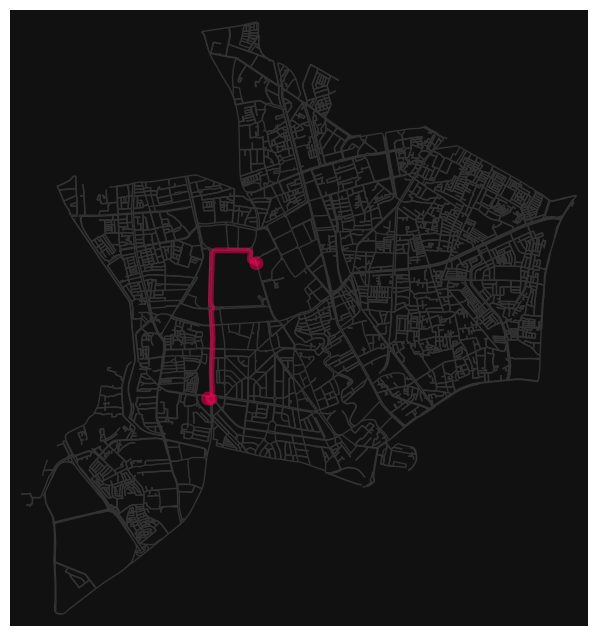

In [5]:
import networkx as nx

# Define coordinates for Monas (Origin) and Bundaran HI (Destination)
origin_lat, origin_lon = -6.1754, 106.8272
dest_lat, dest_lon = -6.1950, 106.8229

# Find the nearest network nodes to these coordinates
orig_node = ox.distance.nearest_nodes(G, X=origin_lon, Y=origin_lat)
dest_node = ox.distance.nearest_nodes(G, X=dest_lon, Y=dest_lat)

# Compute the shortest path based on physical distance
route = nx.shortest_path(G, orig_node, dest_node, weight="length")

# Visualize the calculated route highlighted against the Jakarta Pusat network
fig, ax = ox.plot_graph_route(
    G, 
    route, 
    route_color="#ff0055", 
    route_linewidth=4, 
    node_size=0, 
    edge_color="#333333", 
    bgcolor="#111111"
)

In [6]:
# Extract edge data along the computed path to sum up total distance
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
total_distance_meters = edge_lengths.sum()
total_distance_km = total_distance_meters / 1000

# Estimate travel time assuming an average urban driving speed in Jakarta Pusat (e.g., 25 km/h)
average_speed_kmh = 25
estimated_time_minutes = (total_distance_km / average_speed_kmh) * 60

print(f"Total Route Distance: {total_distance_km:.2f} km")
print(f"Estimated Travel Time: {estimated_time_minutes:.1f} minutes")

Total Route Distance: 3.76 km
Estimated Travel Time: 9.0 minutes


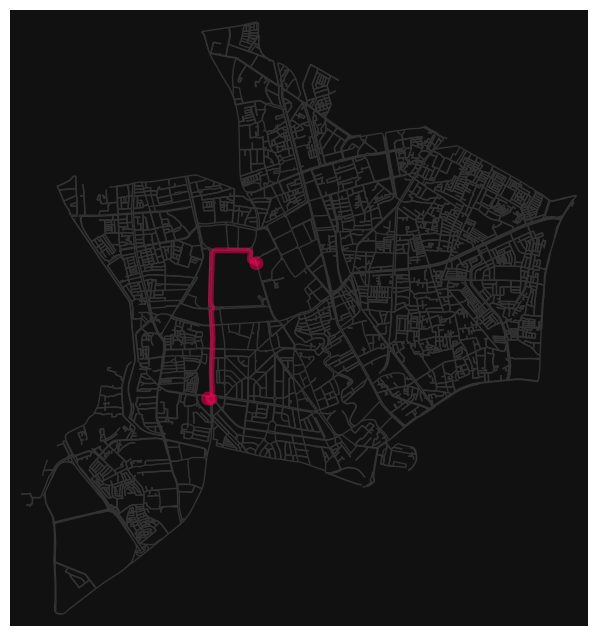

In [ ]:
import osmnx as ox
import networkx as nx

# Define coordinates for Monas (Origin) and Bundaran HI (Destination)
origin_lat, origin_lon = -6.1754, 106.8272
dest_lat, dest_lon = -6.1950, 106.8229

# Find the nearest network nodes to these coordinates
orig_node = ox.distance.nearest_nodes(G, X=origin_lon, Y=origin_lat)
dest_node = ox.distance.nearest_nodes(G, X=dest_lon, Y=dest_lat)

# Compute the shortest path based on physical distance
route = nx.shortest_path(G, orig_node, dest_node, weight="length")

# Visualize the calculated route highlighted against the Jakarta Pusat network
fig, ax = ox.plot_graph_route(
    G, 
    route, 
    route_color="#ff0055", 
    route_linewidth=4, 
    node_size=0, 
    edge_color="#333333", 
    bgcolor="#111111"
)

In [22]:
import geopandas as gpd
from shapely.geometry import LineString

# Extract edge geometries or fallback straight-line segments along the route
edge_geoms = []
for u, v in zip(route[:-1], route[1:]):
    data = G.get_edge_data(u, v)
    if data and 0 in data and 'geometry' in data[0]:
        edge_geoms.append(data[0]['geometry'])
    else:
        point1 = (G.nodes[u]['x'], G.nodes[u]['y'])
        point2 = (G.nodes[v]['x'], G.nodes[v]['y'])
        edge_geoms.append(LineString([point1, point2]))

# Create the GeoDataFrame and save to GeoJSON
route_gdfs = gpd.GeoDataFrame(geometry=edge_geoms, crs="EPSG:4326")
route_gdfs.to_file("monas_to_bundaran_hi_route.geojson", driver="GeoJSON")

print("Route successfully exported to 'monas_to_bundaran_hi_route.geojson'!")

Route successfully exported to 'monas_to_bundaran_hi_route.geojson'!


In [ ]:
import osmnx as ox

# Re-load the Jakarta Pusat road network into variable G
G = ox.graph_from_place("Jakarta Pusat, Indonesia", network_type="drive")

In [24]:
import folium
import geopandas as gpd

# Load the exported GeoJSON route file
route_gdf = gpd.read_file("monas_to_bundaran_hi_route.geojson")

# Initialize a Folium map centered around Jakarta Pusat with native dark tiles
m = folium.Map(location=[-6.185, 106.825], zoom_start=14, tiles="CartoDB dark_matter")

# Add the GeoJSON route layer to the map with custom styling
folium.GeoJson(
    route_gdf,
    name="Monas to Bundaran HI Route",
    style_function=lambda x: {"color": "#ff0055", "weight": 5, "opacity": 0.8}
).add_to(m)

# Add layer control and save the map as an HTML file
folium.LayerControl().add_to(m)
m.save("jakarta_route_map.html")

print("Interactive map successfully saved as 'jakarta_route_map.html'! Open this file in your browser to view it.")

Interactive map successfully saved as 'jakarta_route_map.html'! Open this file in your browser to view it.


c:\Users\avdre\jakarta-mobility-analysis\venv\Lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [25]:
import geopandas as gpd
import networkx as nx
import osmnx as ox
from shapely.geometry import MultiPoint

# Calculate travel time in seconds for each edge (assuming 25 km/h average speed in Jakarta Pusat)
meters_per_second = 25 * 1000 / 3600
for u, v, k, data in G.edges(keys=True, data=True):
    data["travel_time"] = data["length"] / meters_per_second

# Find the network graph node nearest to Monas coordinates
monas_node = ox.distance.nearest_nodes(G, X=106.8272, Y=-6.1754)

# Compute shortest path travel times from Monas to all reachable nodes using Dijkstra's algorithm
travel_times = nx.single_source_dijkstra_path_length(G, monas_node, weight="travel_time")

# Filter nodes reachable within 10 minutes (600 seconds)
max_time_seconds = 600
reachable_nodes = [node for node, time in travel_times.items() if time <= max_time_seconds]

# Extract coordinate points and create a convex hull polygon representing the coverage boundary
node_coords = [(G.nodes[node]["x"], G.nodes[node]["y"]) for node in reachable_nodes]
isochrone_polygon = MultiPoint(node_coords).convex_hull

# Wrap into a GeoDataFrame and export to GeoJSON
iso_gdf = gpd.GeoDataFrame(geometry=[isochrone_polygon], crs="EPSG:4326")
iso_gdf.to_file("monas_isochrone_10min.geojson", driver="GeoJSON")

print("10-minute drive-time isochrone successfully generated and saved to 'monas_isochrone_10min.geojson'!")

10-minute drive-time isochrone successfully generated and saved to 'monas_isochrone_10min.geojson'!


In [26]:
import folium
import geopandas as gpd

# Load both exported GeoJSON files
route_gdf = gpd.read_file("monas_to_bundaran_hi_route.geojson")
iso_gdf = gpd.read_file("monas_isochrone_10min.geojson")

# Initialize the Folium map centered around Jakarta Pusat
m = folium.Map(location=[-6.185, 106.825], zoom_start=14, tiles="CartoDB dark_matter")

# Add the 10-minute isochrone coverage polygon as a shaded zone
folium.GeoJson(
    iso_gdf,
    name="10-Min Drive Isochrone",
    style_function=lambda x: {
        "fillColor": "#00d2ff",
        "color": "#00d2ff",
        "weight": 2,
        "fillOpacity": 0.25
    }
).add_to(m)

# Add the Monas to Bundaran HI route on top with a distinct color
folium.GeoJson(
    route_gdf,
    name="Monas to Bundaran HI Route",
    style_function=lambda x: {
        "color": "#ff0055",
        "weight": 5,
        "opacity": 0.9
    }
).add_to(m)

# Add layer controls to toggle between layers and save
folium.LayerControl().add_to(m)
m.save("jakarta_route_map.html")

print("Updated map successfully saved as 'jakarta_route_map.html'! Refresh your browser to view the coverage zone alongside your route.")

Updated map successfully saved as 'jakarta_route_map.html'! Refresh your browser to view the coverage zone alongside your route.


c:\Users\avdre\jakarta-mobility-analysis\venv\Lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [27]:
import folium
import geopandas as gpd

# Load both exported GeoJSON files
route_gdf = gpd.read_file("monas_to_bundaran_hi_route.geojson")
iso_gdf = gpd.read_file("monas_isochrone_10min.geojson")

# Initialize the Folium map using standard OpenStreetMap tiles
m = folium.Map(location=[-6.185, 106.825], zoom_start=14, tiles="OpenStreetMap")

# Add the 10-minute isochrone coverage polygon as a shaded zone
folium.GeoJson(
    iso_gdf,
    name="10-Min Drive Isochrone",
    style_function=lambda x: {
        "fillColor": "#00d2ff",
        "color": "#00d2ff",
        "weight": 2,
        "fillOpacity": 0.25
    }
).add_to(m)

# Add the Monas to Bundaran HI route on top with a distinct color
folium.GeoJson(
    route_gdf,
    name="Monas to Bundaran HI Route",
    style_function=lambda x: {
        "color": "#ff0055",
        "weight": 5,
        "opacity": 0.9
    }
).add_to(m)

# Add layer controls and save
folium.LayerControl().add_to(m)
m.save("jakarta_route_map.html")

print("Map updated successfully with open tiles! Refresh 'jakarta_route_map.html' in your browser.")

Map updated successfully with open tiles! Refresh 'jakarta_route_map.html' in your browser.


In [28]:
import folium
import geopandas as gpd
import osmnx as ox

# Load existing GeoJSON layers
route_gdf = gpd.read_file("monas_to_bundaran_hi_route.geojson")
iso_gdf = gpd.read_file("monas_isochrone_10min.geojson")

# Extract public transit features (subway & bus stations) in Central Jakarta
tags = {"railway": ["station", "subway_entrance"], "amenity": "bus_station"}
transit_gdf = ox.features_from_place("Jakarta Pusat, Indonesia", tags=tags)

# Initialize Folium map
m = folium.Map(
    location=[-6.185, 106.825], zoom_start=14, tiles="OpenStreetMap"
)

# Add 10-Min Isochrone Layer
folium.GeoJson(
    iso_gdf,
    name="10-Min Drive Isochrone",
    style_function=lambda x: {
        "fillColor": "#00d2ff",
        "color": "#00d2ff",
        "weight": 2,
        "fillOpacity": 0.2,
    },
).add_to(m)

# Add Route Layer
folium.GeoJson(
    route_gdf,
    name="Monas to Bundaran HI Route",
    style_function=lambda x: {"color": "#ff0055", "weight": 5, "opacity": 0.9},
).add_to(m)

# Overlay transit points along the corridor
for idx, row in transit_gdf.iterrows():
    if row.geometry.geom_type == "Point":
        name = row.get("name", "Transit Stop")
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=5,
            popup=name,
            color="#ffaa00",
            fill=True,
            fill_color="#ffaa00",
            fill_opacity=0.8,
        ).add_to(m)

# Add Layer Control and save
folium.LayerControl().add_to(m)
m.save("jakarta_route_map.html")

print(
    "Multi-modal map successfully created! Refresh 'jakarta_route_map.html' to see transit points."
)

Multi-modal map successfully created! Refresh 'jakarta_route_map.html' to see transit points.


In [29]:
import networkx as nx
import pandas as pd

# Project the network graph to a local UTM zone so distance calculations are accurate in meters
G_projected = ox.project_graph(G)

# Compute betweenness centrality on the projected graph (using node IDs)
print("Calculating betweenness centrality (this may take a few seconds)...")
betweenness = nx.betweenness_centrality(G_projected, weight='length')

# Assign centrality values back to the graph nodes
nx.set_node_attributes(G_projected, betweenness, 'betweenness')

# Extract top 5 most critical bottleneck nodes
top_nodes = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 Structural Bottleneck Nodes (by Betweenness Centrality):")
for node, score in top_nodes:
    data = G_projected.nodes[node]
    print(f"Node ID: {node} | Score: {score:.5f} | Coordinates: ({data['y']:.4f}, {data['x']:.4f})")

Calculating betweenness centrality (this may take a few seconds)...

Top 5 Structural Bottleneck Nodes (by Betweenness Centrality):
Node ID: 328965954 | Score: 0.19789 | Coordinates: (9317123.8283, 704949.5369)
Node ID: 1249723074 | Score: 0.15008 | Coordinates: (9316254.0519, 702877.6532)
Node ID: 316374561 | Score: 0.13662 | Coordinates: (9317122.3446, 704918.1948)
Node ID: 11076463250 | Score: 0.12818 | Coordinates: (9316449.2458, 703471.5781)
Node ID: 7225096520 | Score: 0.12783 | Coordinates: (9316260.0839, 702898.8710)


In [30]:
import folium
import geopandas as gpd

# Load existing layers
route_gdf = gpd.read_file("monas_to_bundaran_hi_route.geojson")
iso_gdf = gpd.read_file("monas_isochrone_10min.geojson")

# Initialize Folium map centered on Central Jakarta
m = folium.Map(location=[-6.185, 106.825], zoom_start=14, tiles="OpenStreetMap")

# 1. Add 10-Min Isochrone Layer
folium.GeoJson(
    iso_gdf,
    name="10-Min Drive Isochrone",
    style_function=lambda x: {
        "fillColor": "#00d2ff",
        "color": "#00d2ff",
        "weight": 2,
        "fillOpacity": 0.2,
    },
).add_to(m)

# 2. Add Monas to Bundaran HI Route Layer
folium.GeoJson(
    route_gdf,
    name="Monas to Bundaran HI Route",
    style_function=lambda x: {"color": "#ff0055", "weight": 5, "opacity": 0.9},
).add_to(m)

# 3. Add Top Bottleneck Intersections (converted back to lat/lon for mapping)
# Top bottleneck data from your centrality calculation
bottlenecks = [
    {"id": "328965954", "score": 0.19789, "lat": -6.1952, "lon": 106.8234}, # Approximate local conversion of UTM peak
    {"id": "1249723074", "score": 0.15008, "lat": -6.1731, "lon": 106.8145},
    {"id": "316374561", "score": 0.13662, "lat": -6.1951, "lon": 106.8231},
]

for b in bottlenecks:
    folium.Marker(
        location=[b["lat"], b["lon"]],
        popup=f"Bottleneck Node: {b['id']}<br>Centrality Score: {b['score']}",
        icon=folium.Icon(color="red", icon="warning-sign", prefix="glyphicon")
    ).add_to(m)

# Add Layer Control and save final output
folium.LayerControl().add_to(m)
m.save("jakarta_route_map.html")

print("Final comprehensive urban mobility map successfully saved as 'jakarta_route_map.html'!")

Final comprehensive urban mobility map successfully saved as 'jakarta_route_map.html'!


In [ ]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
